# Shadow Runtime RC-PCNN Backend Comparison

This notebook uses `EPFLpiml/module_shadow___.py`, a refactored shadow module for the current no-occupancy workflow. It keeps the closed-loop runtime RC architecture and lets the neural state backend switch between LSTM and a PCNN-style recurrent feature backend.

The model still does not use precomputed `HeatingEnergy` or `RC heating` inputs.

In [1]:
from pathlib import Path
import sys
import time
import uuid
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RC_SIMULATOR = "ETHlib"

if RC_SIMULATOR not in sys.path:
    sys.path.insert(0, RC_SIMULATOR)

from _ import *
from _BR_ import *
from _zone_ import DebugZone as Zone
from radiation import Window
import supply_system
import emission_system

try:
    import torch
except ImportError as exc:
    raise RuntimeError("Install PyTorch before running this notebook.") from exc

import EPFLpiml.model as pcnn_model
from EPFLpiml.model import Model
from EPFLpiml.parameters import parameters
from EPFLpiml.module_shadow___ import (
    PCNN as ShadowRuntimePCNN,
    ML_BACKEND_BUILDERS,
    inject_ml_backend,
)

pcnn_model.PCNN = ShadowRuntimePCNN
print("Available ML backends:", sorted(ML_BACKEND_BUILDERS))
pcnn_model.check_initialization_physical_parameters = lambda **kwargs: None

FORCE_FRESH_TRAINING = True
RUN_SMOKE = True
RUN_FULL_TRAINING = False
RUN_ABLATIONS = False
RUN_BACKEND_SMOKE_COMPARISON = True
BACKENDS_TO_COMPARE = ["lstm", "pcnn"]

# Optional diagnostic plotting window. Use None for the full period.
DIAGNOSTIC_START = None  # example: "2023-02-01"
DIAGNOSTIC_END = None    # example: "2023-02-07 23:00"

if FORCE_FRESH_TRAINING:
    print("Fresh training: no model or sequence cache loaded")


Available ML backends: ['gru', 'lstm', 'mlp', 'pcnn', 'plugin', 'rnn', 'transformer']
Fresh training: no model or sequence cache loaded


In [2]:
# ============================================================
# 1. ETHlib case construction
# ============================================================

epw_path = Path("../src/_base/epw/ED-TMYx.2023.epw")
if not epw_path.exists():
    epw_path = Path("ETHlib/auxiliary/Zurich-Kloten_2013.epw")

case = RCCase(
    year=2023,
    loc_json=Path("_json/location_params.json"),
    geo_json=Path("_json/geo_params.json"),
    default_json=Path("_json/default_params.json"),
    epw_path=epw_path,
    occupancy_profile_csv=Path("_data/default_occ.csv"),
    Zone=Zone,
    supply_system=supply_system,
    emission_system=emission_system,
)

case.occupancy_profile = (
    pd.read_csv(Path("_data/bldg_LoD.csv"), usecols=["Y"])
    .iloc[:8760]
    .reset_index(drop=True)
)
case.occupancy_profile.columns = ["People"]

p = case.default_params
geometry = case.geometry
year = case.year

ach_vent_baseline, ach_infl_baseline = make_ach(p=p, geometry=geometry, calc_ach=calc_ach)
office = make_zone(
    p=p,
    geometry=geometry,
    ach_vent=ach_vent_baseline,
    ach_infl=ach_infl_baseline,
    Zone=Zone,
    supply_system=supply_system,
    emission_system=emission_system,
)

heating_schedule = make_heating_schedule(year=year, p=p)
design_occupied_schedule = occupancy_default(year)
hr_eff_schedule = make_hr_eff_schedule(p=p, year=year)
ventilation_controller_params = {
    "ach_vent_baseline": ach_vent_baseline,
    "design_occupied_schedule": design_occupied_schedule,
}

south_window = Window(
    azimuth_tilt=0,
    alititude_tilt=90,
    glass_solar_transmittance=0.3,
    glass_light_transmittance=0.3,
    area=geometry["WINDOW_AREA"] * p["_beta"],
)


In [3]:
# ============================================================
# 2. Hourly physical forcings, not RC heating outputs
# ============================================================

full_index = pd.date_range(f"{year}-01-01 00:00:00", periods=8760, freq="h")
rows = []

for hour, timestamp in enumerate(full_index):
    desired_ach = design_schedule_based_ach(hour=hour, **ventilation_controller_params)
    office.ach_vent = desired_ach
    office.ventilation_efficiency = hr_eff_schedule[hour] if desired_ach > 0 else 0.0

    occupancy_fraction = case.occupancy_profile.loc[hour, "People"]
    occupancy = occupancy_fraction * p["max_occupancy"]
    people_gains = occupancy * p["gain_per_person"]
    appliance_gains = occupancy_fraction * p["appliance_gains"] * office.occ_area
    internal_gains = people_gains + appliance_gains

    t_out = case.location.weather_data["drybulb_C"][hour]
    altitude, azimuth = case.location.calc_sun_position(
        latitude_deg=case.latitude_deg,
        longitude_deg=case.longitude_deg,
        year=year,
        hoy=hour,
    )
    south_window.calc_solar_gains(
        sun_altitude=altitude,
        sun_azimuth=azimuth,
        normal_direct_radiation=case.location.weather_data["dirnorrad_Whm2"][hour],
        horizontal_diffuse_radiation=case.location.weather_data["difhorrad_Whm2"][hour],
    )

    rows.append(
        {
            "Internal gains": internal_gains,
            "Solar gains": south_window.solar_gains,
            "Outside temperature": t_out,
            "Heating setpoint": heating_schedule[hour],
            "h_ve_adj": office.h_ve_adj,
        }
    )

rc_inputs = pd.DataFrame(rows, index=full_index)
rc_inputs = rc_inputs.loc["2023-01-20 00:00:00":"2023-03-20 23:00:00"].copy()
print(rc_inputs.describe().T[["mean", "std", "min", "max"]])


                              mean           std           min            max
Internal gains       111178.121732  34345.262611  75416.487644  171478.893311
Solar gains           10924.227660  19584.869696      0.000000  104750.410285
Outside temperature       4.614792      2.852953     -2.900000      11.300000
Heating setpoint         17.275000      2.789225     15.000000      21.000000
h_ve_adj              12816.037417   1356.907735  12006.786667   15089.646667


In [4]:
# ============================================================
# 3. Measured target and one-step alignment
# ============================================================

meter_path = Path("_data/Metering_ISO.csv")
measured_heating = load_meter_heating(meter_path, "Main Heating", geometry["FLOOR_AREA"], "h")
measured_heating.name = "Measured heating"

data = pd.concat([measured_heating, rc_inputs], axis=1, join="inner").sort_index().dropna().copy()
data["Month sin"] = np.sin(2 * np.pi * (data.index.month - 1) / 12)
data["Month cos"] = np.cos(2 * np.pi * (data.index.month - 1) / 12)
data["Weekday"] = data.index.dayofweek
data["Timestep sin"] = np.sin(2 * np.pi * data.index.hour / 24)
data["Timestep cos"] = np.cos(2 * np.pi * data.index.hour / 24)

shadow_data = pd.DataFrame(index=data.index)
shadow_data["Measured heating"] = data["Measured heating"]
future_columns = [
    "Internal gains",
    "Solar gains",
    "Outside temperature",
    "Heating setpoint",
    "h_ve_adj",
    "Month sin",
    "Month cos",
    "Weekday",
    "Timestep sin",
    "Timestep cos",
]
for column in future_columns:
    shadow_data[column] = data[column].shift(-1)

shadow_data["Case"] = 1.0
shadow_data.iloc[0, shadow_data.columns.get_loc("Case")] = 0.0
shadow_data = shadow_data.dropna().copy()

assert "HeatingEnergy" not in shadow_data.columns
assert "RC heating" not in shadow_data.columns
assert "Design occupied" not in shadow_data.columns
assert "Occupancy fraction" not in shadow_data.columns

print("Rows:", len(shadow_data))
print("Period:", shadow_data.index.min(), "to", shadow_data.index.max())
print(shadow_data[future_columns].std().sort_values())
display(shadow_data.head())


Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00
Rows: 1439
Period: 2023-01-20 00:00:00 to 2023-03-20 22:00:00
Month cos                  0.197991
Month sin                  0.306782
Timestep cos               0.707106
Timestep sin               0.707598
Weekday                    2.029596
Heating setpoint           2.789549
Outside temperature        2.851568
h_ve_adj                1357.211574
Solar gains            19589.558711
Internal gains         34348.990661
dtype: float64


,Measured heating,Internal gains,Solar gains,Outside temperature,Heating setpoint,h_ve_adj,Month sin,Month cos,Weekday,Timestep sin,Timestep cos,Case
2023-01-20 00:00:00,0.014547,79776.571942,0.0,0.0,15.0,12006.786667,0.0,1.0,4.0,0.258819,0.965926,0.0
2023-01-20 01:00:00,0.014547,78245.183348,0.0,-0.2,15.0,12006.786667,0.0,1.0,4.0,0.500000,0.866025,1.0
2023-01-20 02:00:00,0.014547,77292.984808,0.0,-0.4,15.0,12006.786667,0.0,1.0,4.0,0.707107,0.707107,1.0
2023-01-20 03:00:00,0.014547,79633.894466,0.0,-0.6,15.0,12006.786667,0.0,1.0,4.0,0.866025,0.500000,1.0
2023-01-20 04:00:00,0.014547,80579.207630,0.0,-0.8,15.0,12006.786667,0.0,1.0,4.0,0.965926,0.258819,1.0


In [5]:
# ============================================================
# 4. Data and model parameters
# ============================================================

data_params = dict(
    temperature_column=["Measured heating"],
    power_column=["Internal gains", "Solar gains", "Heating setpoint", "h_ve_adj"],
    case_column="Case",
    out_column="Outside temperature",
    neigh_column=None,
    inputs_D=["Month sin", "Month cos", "Weekday", "Timestep sin", "Timestep cos"],
    outside_walls=[0],
    neighboring_rooms=[],
    seed=0,
)

run_id = uuid.uuid4().hex[:8] if FORCE_FRESH_TRAINING else "cached"
base_model_params = parameters(
    name=f"shadow_runtime_RC_{run_id}",
    seed=0,
    overlapping_distance=4,
    warm_start_length=12,
    maximum_sequence_length=24 * 3,
    minimum_sequence_length=24,
    learn_initial_hidden_states=True,
    decrease_learning_rate=False,
    learning_rate=0.0003,
    feed_input_through_nn=True,
    input_nn_hidden_sizes=[32],
    lstm_hidden_size=64,
    lstm_num_layers=2,
    layer_norm=True,
    batch_size=256,
    output_nn_hidden_sizes=[32],
    division_factor=10.0,
    device="cpu",
    verbose=2,
    save=False,
)
base_model_params.update(
    {
        "validation_percentage": 0.10,
        "test_percentage": 0.20,
        "heating": True,
        "cooling": False,
        "initial_values_physical_parameters": {"a": [1.0], "b": [1.0], "c": [1.0], "d": [1.0]},
        "rc_case": case,
        "rc_initial_state": 20.0,
        "rc_internal_gains_column": "Internal gains",
        "rc_solar_gains_column": "Solar gains",
        "rc_t_out_column": "Outside temperature",
        "rc_t_set_heating_column": "Heating setpoint",
        "rc_h_ve_adj_column": "h_ve_adj",
        "d_extra_input_columns": [],
        "include_previous_target_in_D": True,
        "include_runtime_E_in_D": True,
        "include_physical_inputs_in_D": True,
        "include_out_column_in_D": True,
        "strict_required_inputs": True,
        "validate_neural_input_variation": True,
        "use_baseline_branch": True,
        "use_discrepancy_branch": True,
        "trainable_rc": False,
        "neural_backend": "lstm",
        "neural_hidden_size": 64,
        "neural_num_layers": 2,
        "pcnn_accumulator_decay": 0.98,
        "pcnn_accumulator_scale": 0.03,
        "baseline_hidden_sizes": [16],
        "discrepancy_hidden_sizes": [16],
        "discrepancy_fraction_of_target_range": 0.10,
        "baseline_fraction_of_target_range": 0.08,
        "baseline_scale": None,
        "enforce_nonnegative_output": True,
    }
)
base_model_params["division_factor"] = float(np.asarray(base_model_params["division_factor"], dtype=float).reshape(-1)[0])

ABLATION = "E_plus_B_plus_D_lstm"
ABLATIONS = {
    "E_only": dict(use_baseline_branch=False, use_discrepancy_branch=False),
    "E_plus_D": dict(use_baseline_branch=False, use_discrepancy_branch=True),
    "E_plus_B": dict(use_baseline_branch=True, use_discrepancy_branch=False),
    "E_plus_B_plus_D_lstm": dict(
        use_baseline_branch=True,
        use_discrepancy_branch=True,
        neural_backend="lstm",
    ),
    "E_plus_B_plus_D_gru": dict(
        use_baseline_branch=True,
        use_discrepancy_branch=True,
        neural_backend="gru",
    ),
    "E_plus_B_plus_D_rnn": dict(
        use_baseline_branch=True,
        use_discrepancy_branch=True,
        neural_backend="rnn",
    ),
    "E_plus_B_plus_D_mlp": dict(
        use_baseline_branch=True,
        use_discrepancy_branch=True,
        neural_backend="mlp",
    ),
    "E_plus_B_plus_D_pcnn": dict(
        use_baseline_branch=True,
        use_discrepancy_branch=True,
        neural_backend="pcnn",
    ),
    # Placeholder: provide neural_backend_factory in model_params to test a
    # time-series library transformer with the same forward contract.
    # "E_plus_B_plus_D_transformer": dict(
    #     use_baseline_branch=True,
    #     use_discrepancy_branch=True,
    #     neural_backend="transformer",
    #     neural_backend_factory=your_factory,
    # ),
}
model_params = base_model_params.copy()
model_params.update(ABLATIONS[ABLATION])
model_params["name"] = f"{base_model_params['name']}_{ABLATION}"


In [6]:
# ============================================================
# 5. Diagnostics helpers
# ============================================================

def inverse_target(values, piml):
    target_min = float(np.asarray(piml.model_kwargs["temperature_min"]).reshape(-1)[0])
    target_range = float(np.asarray(piml.model_kwargs["temperature_range"]).reshape(-1)[0])
    return (values - 0.1) / 0.8 * target_range + target_min


def snapshot_parameters(model):
    return {name: p.detach().clone() for name, p in model.named_parameters() if p.requires_grad}


def parameter_change_norm(before, model, prefix=None):
    total = 0.0
    for name, p in model.named_parameters():
        if not p.requires_grad or name not in before:
            continue
        if prefix is not None and not name.startswith(prefix):
            continue
        delta = p.detach() - before[name]
        total += float(torch.sum(delta * delta).detach().cpu())
    return math.sqrt(total)


def trainable_parameter_summary(model):
    rows = [(name, int(p.numel())) for name, p in model.named_parameters() if p.requires_grad]
    print("trainable parameters:", sum(n for _, n in rows))
    for name, n in rows[:20]:
        print(f"  {name}: {n}")
    if len(rows) > 20:
        print("  ...")


def gradient_check_one_batch(piml):
    batch_sequences = next(piml.batch_iterator(iterator_type="train", batch_size=min(8, len(piml.train_sequences)), shuffle=False))
    piml.model.train()
    piml.optimizer.zero_grad(set_to_none=True)
    loss = piml.compute_loss(batch_sequences)
    loss.backward()
    groups = {"sequence_model": 0.0, "baseline_head": 0.0, "discrepancy_head": 0.0}
    for name, p in piml.model.named_parameters():
        if p.requires_grad and p.grad is not None:
            for group in groups:
                if name.startswith(group):
                    groups[group] += float(p.grad.norm().detach().cpu())
    print("one-batch loss:", float(loss.detach().cpu()))
    print("gradient norms:", groups)
    piml.optimizer.zero_grad(set_to_none=True)
    return groups


def rollout_with_diagnostics(piml):
    piml.model.eval()
    batch_x = piml.X.reshape(1, piml.X.shape[0], -1)
    batch_y = piml.Y.reshape(1, piml.Y.shape[0], piml.number_rooms)
    predictions, E_values, B_values, D_values, Q_values = [], [], [], [], []
    states = None
    with torch.no_grad():
        for i in range(batch_x.shape[1]):
            pred, states = piml.model(batch_x[:, i, :], states, warm_start=i < piml.warm_start_length)
            predictions.append(pred[:, 0].detach().cpu().numpy())
            E_values.append(piml.model.last_E.detach().cpu().numpy()[:, 0])
            B_values.append(piml.model.last_B.detach().cpu().numpy()[:, 0])
            D_values.append(piml.model.last_D.detach().cpu().numpy()[:, 0])
            Q_values.append(piml.model.last_q_prediction.detach().cpu().numpy()[:, 0])
    pred_norm = np.asarray(predictions)[:, 0]
    measured_norm = batch_y.detach().cpu().numpy()[0, :, 0]
    return pd.DataFrame(
        {
            "Measured": inverse_target(measured_norm, piml),
            "Prediction": inverse_target(pred_norm, piml),
            "E": np.asarray(E_values)[:, 0],
            "B": np.asarray(B_values)[:, 0],
            "D": np.asarray(D_values)[:, 0],
            "Q": np.asarray(Q_values)[:, 0],
        },
        index=shadow_data.index[1:1 + len(pred_norm)],
    )


def contribution_stats(diagnostics):
    regimes = {
        "whole_period": np.ones(len(diagnostics), dtype=bool),
        "E_zero": diagnostics["E"].abs().to_numpy() <= 1e-10,
        "E_positive": diagnostics["E"].to_numpy() > 1e-10,
    }
    rows = []
    for name, mask in regimes.items():
        subset = diagnostics.loc[mask]
        row = {"regime": name, "n": len(subset)}
        for column in ["E", "B", "D", "Prediction"]:
            row[f"{column}_mean"] = subset[column].mean()
            row[f"{column}_std"] = subset[column].std()
        rows.append(row)
    return pd.DataFrame(rows)


def hourly_metrics(frame):
    observed = frame["Measured"].to_numpy(dtype=float)
    predicted = frame["Prediction"].to_numpy(dtype=float)
    valid = np.isfinite(observed) & np.isfinite(predicted)
    observed = observed[valid]
    predicted = predicted[valid]
    if len(observed) == 0 or np.isclose(observed.mean(), 0.0):
        return pd.Series({"CVRMSE_%": np.nan, "NMBE_%": np.nan, "n": len(observed)})
    err = predicted - observed
    return pd.Series({"CVRMSE_%": 100 * np.sqrt(np.mean(err ** 2)) / observed.mean(), "NMBE_%": 100 * err.mean() / observed.mean(), "n": len(observed)})


def daily_metrics(frame):
    return hourly_metrics(frame[["Measured", "Prediction"]].resample("D").sum())


def metric_table(diagnostics):
    regimes = {
        "whole_period": np.ones(len(diagnostics), dtype=bool),
        "E_zero": diagnostics["E"].abs().to_numpy() <= 1e-10,
        "E_positive": diagnostics["E"].to_numpy() > 1e-10,
    }
    rows = []
    for name, mask in regimes.items():
        subset = diagnostics.loc[mask]
        h = hourly_metrics(subset)
        d = daily_metrics(subset)
        rows.append({"regime": name, "hourly_CVRMSE_%": h["CVRMSE_%"], "hourly_NMBE_%": h["NMBE_%"], "daily_CVRMSE_%": d["CVRMSE_%"], "daily_NMBE_%": d["NMBE_%"], "n_hours": int(h["n"]), "B_mean": subset["B"].mean(), "B_std": subset["B"].std()})
    return pd.DataFrame(rows)



def run_shadow_diagnostics(diagnostics, label, start=None, end=None):
    if start is not None or end is not None:
        diagnostics = diagnostics.loc[start:end]

    print(f"\n=== {label} ===")
    print("Period:", diagnostics.index.min(), "to", diagnostics.index.max())
    display(contribution_stats(diagnostics))
    display(metric_table(diagnostics))

    ax = diagnostics[["Measured", "E", "Prediction"]].plot(
        figsize=(14, 5),
        linewidth=1.2,
        grid=True,
        title=f"{label}: measured vs 5R1C E vs PIML",
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Hourly heating energy use")
    plt.tight_layout()
    plt.show()

    ax = diagnostics[["E", "B", "D", "Prediction"]].plot(
        figsize=(14, 5),
        linewidth=1.1,
        grid=True,
        title=f"{label}: PIML contributions",
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Hourly heating energy use")
    plt.tight_layout()
    plt.show()

    return diagnostics

def fit_with_diagnostics(piml, n_epochs, number_sequences, output_best):
    before = snapshot_parameters(piml.model)
    n_train = min(len(piml.train_sequences), number_sequences) if number_sequences is not None else len(piml.train_sequences)
    n_batches = int(math.ceil(n_train / piml.batch_size)) if n_train else 0
    expected_steps = n_epochs * n_batches
    start = time.perf_counter()
    piml.fit(n_epochs=n_epochs, number_sequences=number_sequences, output_best=output_best)
    elapsed = time.perf_counter() - start
    print("number of optimiser steps:", expected_steps)
    print("elapsed training time:", elapsed)
    print("parameter-change norm total:", parameter_change_norm(before, piml.model))
    print("parameter-change norm sequence model:", parameter_change_norm(before, piml.model, "sequence_model"))
    print("parameter-change norm baseline:", parameter_change_norm(before, piml.model, "baseline_head"))
    print("parameter-change norm discrepancy:", parameter_change_norm(before, piml.model, "discrepancy_head"))
    return {"elapsed": elapsed, "expected_steps": expected_steps}


2026-06-25 23:30:59.497 | INFO     | EPFLpiml.data:__init__:12 - Preparing the data...
2026-06-25 23:30:59.499 | INFO     | EPFLpiml.data:check_columns:115 - Sanity check of the columns:
[('Case', ['Case']), ('Target', ['Measured heating']), ('RC prediction', ['Internal gains', 'Solar gains', 'Heating setpoint', 'h_ve_adj']), ('Outside temperature', ['Outside temperature'])]
2026-06-25 23:30:59.500 | INFO     | EPFLpiml.data:check_columns:133 - Inputs used in D:
['Month sin', 'Month cos', 'Weekday', 'Timestep sin', 'Timestep cos']
2026-06-25 23:30:59.500 | INFO     | EPFLpiml.data:__init__:46 - Normalizing the data...
2026-06-25 23:30:59.505 | INFO     | EPFLpiml.data:prepare_data:254 - Data ready!

2026-06-25 23:31:00.045 | INFO     | EPFLpiml.model:get_sequences:280 - Trying to load the predictable sequences, where the data has no missing values...
2026-06-25 23:31:00.045 | INFO     | EPFLpiml.model:get_sequences:296 - Nothing found, building the sequences...
2026-06-25 23:31:00.046 

train sequences: 225
validation sequences: 15
test sequences: 70
neural backend: lstm
trainable parameters: 61282
  initial_h: 128
  initial_c: 128
  input_nn.0.0.weight: 384
  input_nn.0.0.bias: 32
  sequence_model.weight_ih_l0: 8192
  sequence_model.weight_hh_l0: 16384
  sequence_model.bias_ih_l0: 256
  sequence_model.bias_hh_l0: 256
  sequence_model.weight_ih_l1: 16384
  sequence_model.weight_hh_l1: 16384
  sequence_model.bias_ih_l1: 256
  sequence_model.bias_hh_l1: 256
  norm.weight: 64
  norm.bias: 64
  baseline_head.0.weight: 1024
  baseline_head.0.bias: 16
  baseline_head.2.weight: 16
  baseline_head.2.bias: 1
  discrepancy_head.0.weight: 1024
  discrepancy_head.0.bias: 16
  ...
Initial B mean: 1.0043743e-05
Initial B max: 1.0046693e-05

=== Before training ===
Period: 2023-01-20 01:00:00 to 2023-03-20 22:00:00


,regime,n,E_mean,E_std,B_mean,B_std,D_mean,D_std,Prediction_mean,Prediction_std
0,whole_period,1438,0.009429,0.013849,0.00001,6.762780e-10,0.001906,0.000874,0.011353,0.013763
1,E_zero,776,0.000000,0.000000,0.00001,2.593188e-10,0.001951,0.000776,0.001976,0.000716
2,E_positive,662,0.020482,0.013793,0.00001,8.286651e-10,0.001854,0.000976,0.022346,0.013673


,regime,hourly_CVRMSE_%,hourly_NMBE_%,daily_CVRMSE_%,daily_NMBE_%,n_hours,B_mean,B_std
0,whole_period,88.916689,-2.490520,29.029460,-2.490520,1438,0.00001,6.762780e-10
1,E_zero,132.954074,-67.984261,83.477751,-67.984261,776,0.00001,2.593188e-10
2,E_positive,68.701162,23.747859,44.211799,23.747860,662,0.00001,8.286651e-10


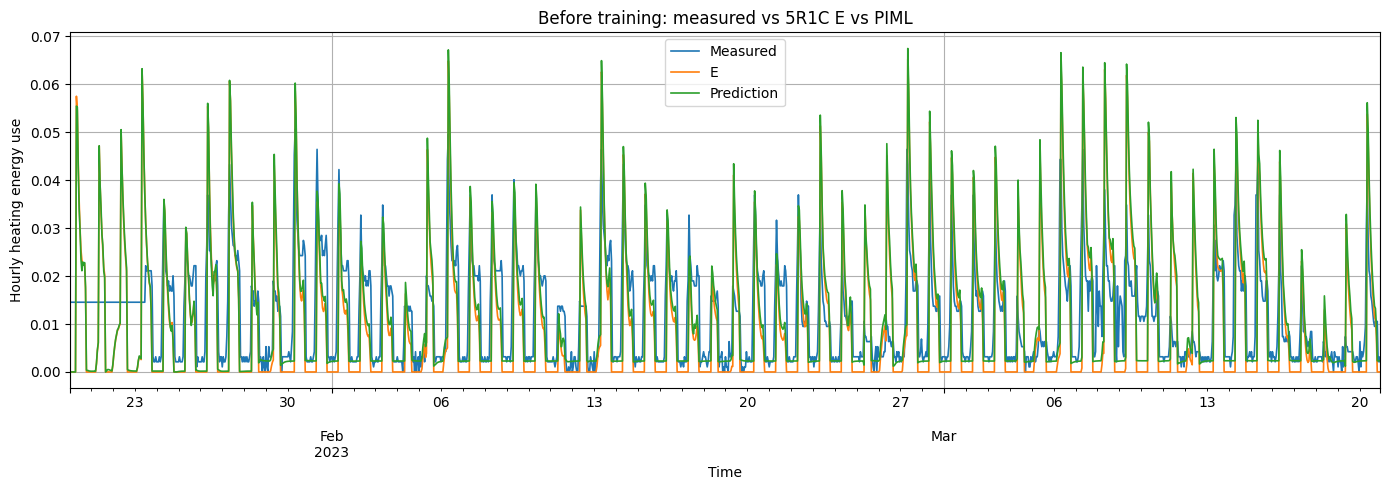

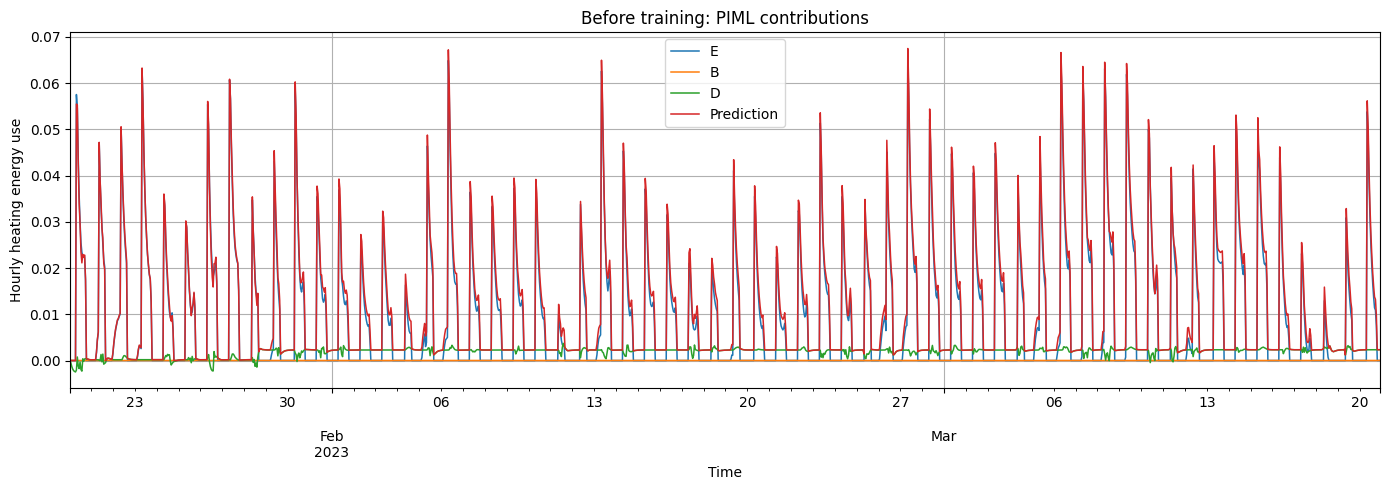

one-batch loss: 0.05998437851667404
gradient norms: {'sequence_model': 0.6062175209845009, 'baseline_head': 8.170826804132503e-05, 'discrepancy_head': 0.10612107440829277}


In [7]:
# ============================================================
# 6. Build fresh model and prove trainability before fitting
# ============================================================

piml = Model(data=shadow_data, module="PCNN", model_params=model_params, data_params=data_params, load=False if FORCE_FRESH_TRAINING else True)
print("train sequences:", len(piml.train_sequences))
print("validation sequences:", len(piml.validation_sequences))
print("test sequences:", len(piml.test_sequences))
print("neural backend:", piml.model.neural_backend)
assert len(piml.train_sequences) > 0
trainable_parameter_summary(piml.model)

pre_diagnostics = rollout_with_diagnostics(piml)
print("Initial B mean:", pre_diagnostics["B"].mean())
print("Initial B max:", pre_diagnostics["B"].max())
pre_plot_diagnostics = run_shadow_diagnostics(
    pre_diagnostics,
    label="Before training",
    start=DIAGNOSTIC_START,
    end=DIAGNOSTIC_END,
)

grad_groups = gradient_check_one_batch(piml)
if piml.model.baseline_head is not None:
    assert grad_groups["baseline_head"] > 0, "baseline branch has zero gradient"
if piml.model.discrepancy_head is not None:
    assert grad_groups["discrepancy_head"] > 0, "discrepancy branch has zero gradient"
assert grad_groups["sequence_model"] > 0, "sequence model has zero gradient"


2026-06-25 23:31:01.370 | INFO     | EPFLpiml.model:fit:653 - Training starts! 8 train, 8 validation, and 8 test sequences.



Epoch	Train loss	Val loss	Test loss	Time
0	6.00E-02	3.41E-02	5.27E-02	00:00:00
1	6.00E-02	3.30E-02	4.88E-02	00:00:00	New best!
2	5.57E-02	3.01E-02	4.47E-02	00:00:00	New best!


2026-06-25 23:31:02.794 | INFO     | EPFLpiml.model:fit:779 - The best model was obtained at epoch 2 after training for 2 epochs in 00:00:00
2026-06-25 23:31:02.794 | INFO     | EPFLpiml.model:fit:780 - Train loss:	5.57E-02
2026-06-25 23:31:02.795 | INFO     | EPFLpiml.model:fit:781 - Val loss:	3.01E-02
2026-06-25 23:31:02.795 | INFO     | EPFLpiml.model:fit:782 - Test loss:	4.47E-02


number of optimiser steps: 2
elapsed training time: 1.4247632079932373
parameter-change norm total: 0.09020738687609406
parameter-change norm sequence model: 0.08800702451268146
parameter-change norm baseline: 0.0039808383534320774
parameter-change norm discrepancy: 0.015664871803226798

=== After smoke training ===
Period: 2023-01-20 01:00:00 to 2023-03-20 22:00:00


,regime,n,E_mean,E_std,B_mean,B_std,D_mean,D_std,Prediction_mean,Prediction_std
0,whole_period,1438,0.00814,0.012621,0.00001,2.689132e-09,0.003810,0.000769,0.011960,0.012426
1,E_zero,817,0.00000,0.000000,0.00001,1.288268e-09,0.003993,0.000419,0.004003,0.000419
2,E_positive,621,0.01885,0.012921,0.00001,3.496820e-09,0.003569,0.001019,0.022429,0.012823


,regime,hourly_CVRMSE_%,hourly_NMBE_%,daily_CVRMSE_%,daily_NMBE_%,n_hours,B_mean,B_std
0,whole_period,82.672895,2.724498,28.884260,2.724498,1438,0.00001,2.689132e-09
1,E_zero,117.411730,-36.502720,60.946684,-36.502720,817,0.00001,1.288268e-09
2,E_positive,63.941844,20.155963,45.311803,20.155963,621,0.00001,3.496820e-09


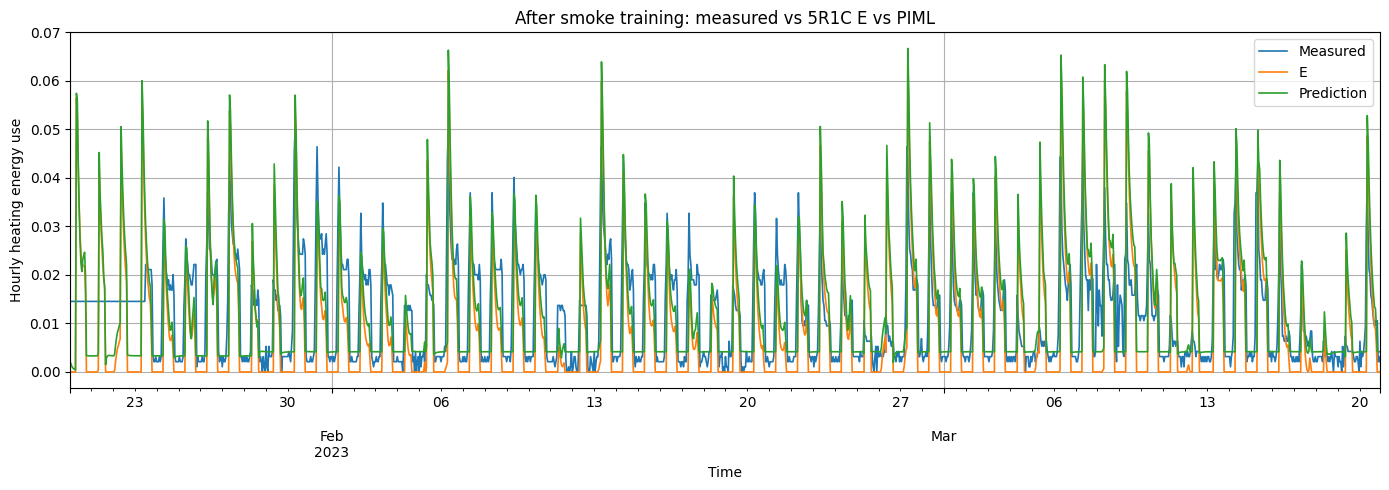

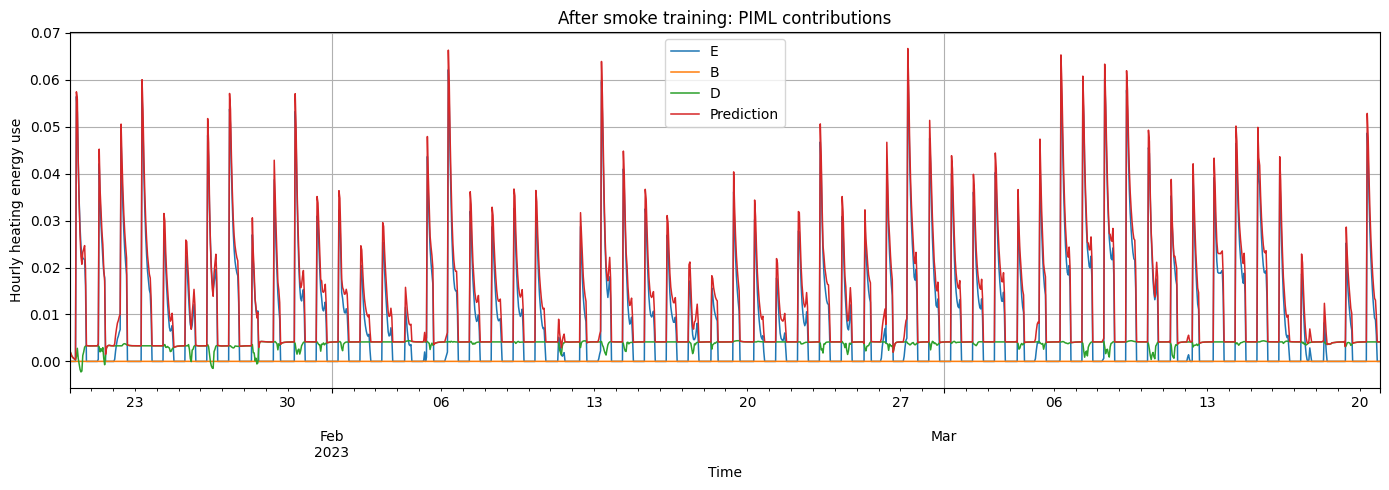

In [8]:
# ============================================================
# 7. Smoke training
# ============================================================

if RUN_SMOKE:
    smoke_info = fit_with_diagnostics(piml, n_epochs=2, number_sequences=8, output_best=False)

post_smoke_diagnostics = rollout_with_diagnostics(piml)
post_smoke_plot_diagnostics = run_shadow_diagnostics(
    post_smoke_diagnostics,
    label="After smoke training",
    start=DIAGNOSTIC_START,
    end=DIAGNOSTIC_END,
)


2026-06-25 23:31:04.000 | INFO     | EPFLpiml.data:__init__:12 - Preparing the data...
2026-06-25 23:31:04.002 | INFO     | EPFLpiml.data:check_columns:115 - Sanity check of the columns:
[('Case', ['Case']), ('Target', ['Measured heating']), ('RC prediction', ['Internal gains', 'Solar gains', 'Heating setpoint', 'h_ve_adj']), ('Outside temperature', ['Outside temperature'])]
2026-06-25 23:31:04.003 | INFO     | EPFLpiml.data:check_columns:133 - Inputs used in D:
['Month sin', 'Month cos', 'Weekday', 'Timestep sin', 'Timestep cos']
2026-06-25 23:31:04.003 | INFO     | EPFLpiml.data:__init__:46 - Normalizing the data...
2026-06-25 23:31:04.007 | INFO     | EPFLpiml.data:prepare_data:254 - Data ready!

2026-06-25 23:31:04.013 | INFO     | EPFLpiml.model:get_sequences:280 - Trying to load the predictable sequences, where the data has no missing values...
2026-06-25 23:31:04.013 | INFO     | EPFLpiml.model:get_sequences:296 - Nothing found, building the sequences...
2026-06-25 23:31:04.015 

Backend: lstm
train sequences: 225
validation sequences: 15
test sequences: 70
trainable parameters: 61282
  initial_h: 128
  initial_c: 128
  input_nn.0.0.weight: 384
  input_nn.0.0.bias: 32
  sequence_model.weight_ih_l0: 8192
  sequence_model.weight_hh_l0: 16384
  sequence_model.bias_ih_l0: 256
  sequence_model.bias_hh_l0: 256
  sequence_model.weight_ih_l1: 16384
  sequence_model.weight_hh_l1: 16384
  sequence_model.bias_ih_l1: 256
  sequence_model.bias_hh_l1: 256
  norm.weight: 64
  norm.bias: 64
  baseline_head.0.weight: 1024
  baseline_head.0.bias: 16
  baseline_head.2.weight: 16
  baseline_head.2.bias: 1
  discrepancy_head.0.weight: 1024
  discrepancy_head.0.bias: 16
  ...
one-batch loss: 0.05998437851667404
gradient norms: {'sequence_model': 0.6062175209845009, 'baseline_head': 8.170826804132503e-05, 'discrepancy_head': 0.10612107440829277}
Epoch	Train loss	Val loss	Test loss	Time
0	6.00E-02	3.41E-02	5.27E-02	00:00:00
1	6.00E-02	3.30E-02	4.88E-02	00:00:00	New best!
2	5.57E-02	3.

2026-06-25 23:31:05.638 | INFO     | EPFLpiml.model:fit:779 - The best model was obtained at epoch 2 after training for 2 epochs in 00:00:00
2026-06-25 23:31:05.641 | INFO     | EPFLpiml.model:fit:780 - Train loss:	5.57E-02
2026-06-25 23:31:05.642 | INFO     | EPFLpiml.model:fit:781 - Val loss:	3.01E-02
2026-06-25 23:31:05.643 | INFO     | EPFLpiml.model:fit:782 - Test loss:	4.47E-02


number of optimiser steps: 2
elapsed training time: 1.4553402910241857
parameter-change norm total: 0.09020738687609406
parameter-change norm sequence model: 0.08800702451268146
parameter-change norm baseline: 0.0039808383534320774
parameter-change norm discrepancy: 0.015664871803226798


2026-06-25 23:31:06.523 | INFO     | EPFLpiml.data:__init__:12 - Preparing the data...
2026-06-25 23:31:06.524 | INFO     | EPFLpiml.data:check_columns:115 - Sanity check of the columns:
[('Case', ['Case']), ('Target', ['Measured heating']), ('RC prediction', ['Internal gains', 'Solar gains', 'Heating setpoint', 'h_ve_adj']), ('Outside temperature', ['Outside temperature'])]
2026-06-25 23:31:06.524 | INFO     | EPFLpiml.data:check_columns:133 - Inputs used in D:
['Month sin', 'Month cos', 'Weekday', 'Timestep sin', 'Timestep cos']
2026-06-25 23:31:06.524 | INFO     | EPFLpiml.data:__init__:46 - Normalizing the data...
2026-06-25 23:31:06.528 | INFO     | EPFLpiml.data:prepare_data:254 - Data ready!

2026-06-25 23:31:06.532 | INFO     | EPFLpiml.model:get_sequences:280 - Trying to load the predictable sequences, where the data has no missing values...
2026-06-25 23:31:06.532 | INFO     | EPFLpiml.model:get_sequences:296 - Nothing found, building the sequences...
2026-06-25 23:31:06.533 

Backend: pcnn
train sequences: 225
validation sequences: 15
test sequences: 70
trainable parameters: 71394
  input_nn.0.0.weight: 384
  input_nn.0.0.bias: 32
  sequence_model.log_accumulator_weight: 2048
  sequence_model.accumulator_bias: 64
  sequence_model.lstm.weight_ih_l0: 8192
  sequence_model.lstm.weight_hh_l0: 16384
  sequence_model.lstm.bias_ih_l0: 256
  sequence_model.lstm.bias_hh_l0: 256
  sequence_model.lstm.weight_ih_l1: 16384
  sequence_model.lstm.weight_hh_l1: 16384
  sequence_model.lstm.bias_ih_l1: 256
  sequence_model.lstm.bias_hh_l1: 256
  sequence_model.mix.0.weight: 8192
  sequence_model.mix.0.bias: 64
  norm.weight: 64
  norm.bias: 64
  baseline_head.0.weight: 1024
  baseline_head.0.bias: 16
  baseline_head.2.weight: 16
  baseline_head.2.bias: 1
  ...
one-batch loss: 0.05126611888408661
gradient norms: {'sequence_model': 0.23128778350098855, 'baseline_head': 0.00017748755623880896, 'discrepancy_head': 0.1324526248499751}
Epoch	Train loss	Val loss	Test loss	Time
0	5.

2026-06-25 23:31:08.143 | INFO     | EPFLpiml.model:fit:779 - The best model was obtained at epoch 2 after training for 2 epochs in 00:00:00
2026-06-25 23:31:08.144 | INFO     | EPFLpiml.model:fit:780 - Train loss:	4.85E-02
2026-06-25 23:31:08.145 | INFO     | EPFLpiml.model:fit:781 - Val loss:	2.69E-02
2026-06-25 23:31:08.145 | INFO     | EPFLpiml.model:fit:782 - Test loss:	4.04E-02


number of optimiser steps: 2
elapsed training time: 1.4627005830116104
parameter-change norm total: 0.10890086050501156
parameter-change norm sequence model: 0.10773368660111092
parameter-change norm baseline: 0.004850937985515943
parameter-change norm discrepancy: 0.01256583636155159


,regime,hourly_CVRMSE_%,hourly_NMBE_%,daily_CVRMSE_%,daily_NMBE_%,n_hours,B_mean,B_std,backend,elapsed_training_time,optimizer_steps
0,whole_period,82.672895,2.724498,28.884260,2.724498,1438,0.00001,2.689132e-09,lstm,1.455340,2
1,E_zero,117.411730,-36.502720,60.946684,-36.502720,817,0.00001,1.288268e-09,lstm,1.455340,2
2,E_positive,63.941844,20.155963,45.311803,20.155963,621,0.00001,3.496820e-09,lstm,1.455340,2
3,whole_period,82.322654,3.521678,28.861631,3.521678,1438,0.00001,1.266345e-09,pcnn,1.462701,2
4,E_zero,114.941673,-34.614884,58.580088,-34.614884,822,0.00001,7.516509e-10,pcnn,1.462701,2
5,E_positive,64.011401,20.788045,46.080298,20.788045,616,0.00001,1.047979e-09,pcnn,1.462701,2


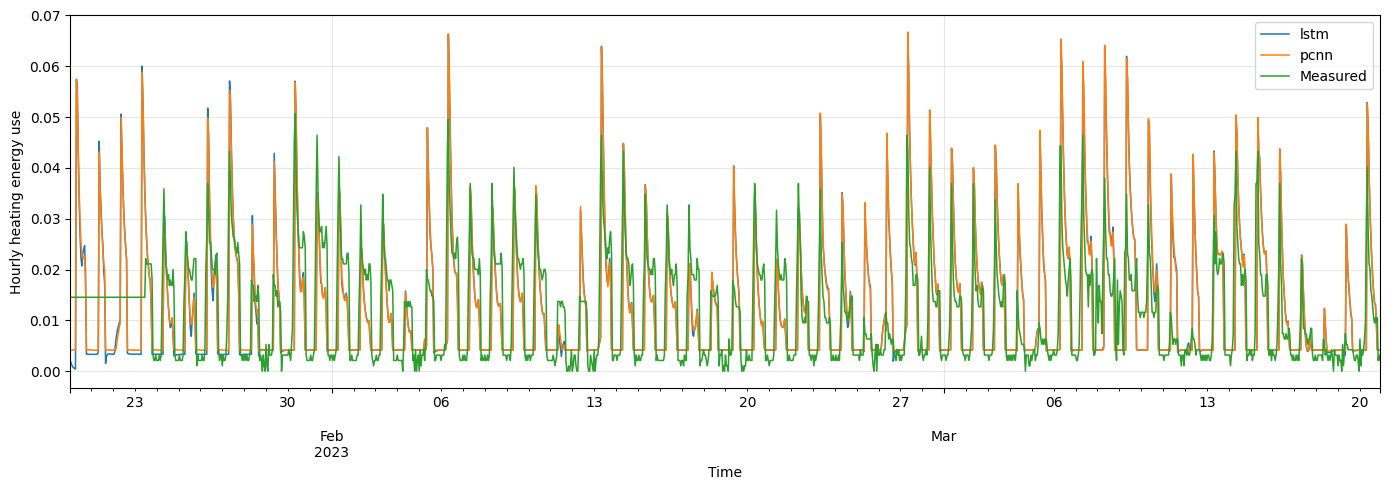

In [9]:
# ============================================================
# 7b. Compare LSTM and PCNN-style neural backends on the same split
# ============================================================

backend_comparison = {}
if RUN_BACKEND_SMOKE_COMPARISON:
    for backend in BACKENDS_TO_COMPARE:
        print("Backend:", backend)
        params = base_model_params.copy()
        params.update(
            dict(
                use_baseline_branch=True,
                use_discrepancy_branch=True,
                neural_backend=backend,
            )
        )
        params["name"] = f"{base_model_params['name']}_backend_{backend}"
        model = Model(
            data=shadow_data,
            module="PCNN",
            model_params=params,
            data_params=data_params,
            load=False,
        )
        print("train sequences:", len(model.train_sequences))
        print("validation sequences:", len(model.validation_sequences))
        print("test sequences:", len(model.test_sequences))
        trainable_parameter_summary(model.model)
        gradient_check_one_batch(model)
        info = fit_with_diagnostics(
            model,
            n_epochs=2,
            number_sequences=8,
            output_best=False,
        )
        diag = rollout_with_diagnostics(model)
        table = metric_table(diag)
        table["backend"] = backend
        table["elapsed_training_time"] = info["elapsed"]
        table["optimizer_steps"] = info["expected_steps"]
        backend_comparison[backend] = dict(
            model=model,
            diagnostics=diag,
            metrics=table,
        )

    comparison_table = pd.concat(
        [item["metrics"] for item in backend_comparison.values()],
        ignore_index=True,
    )
    display(comparison_table)

    ax = pd.DataFrame(
        {
            backend: item["diagnostics"]["Prediction"]
            for backend, item in backend_comparison.items()
        }
    ).join(post_smoke_diagnostics["Measured"]).plot(figsize=(14, 5), linewidth=1.1)
    ax.set_xlabel("Time")
    ax.set_ylabel("Hourly heating energy use")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


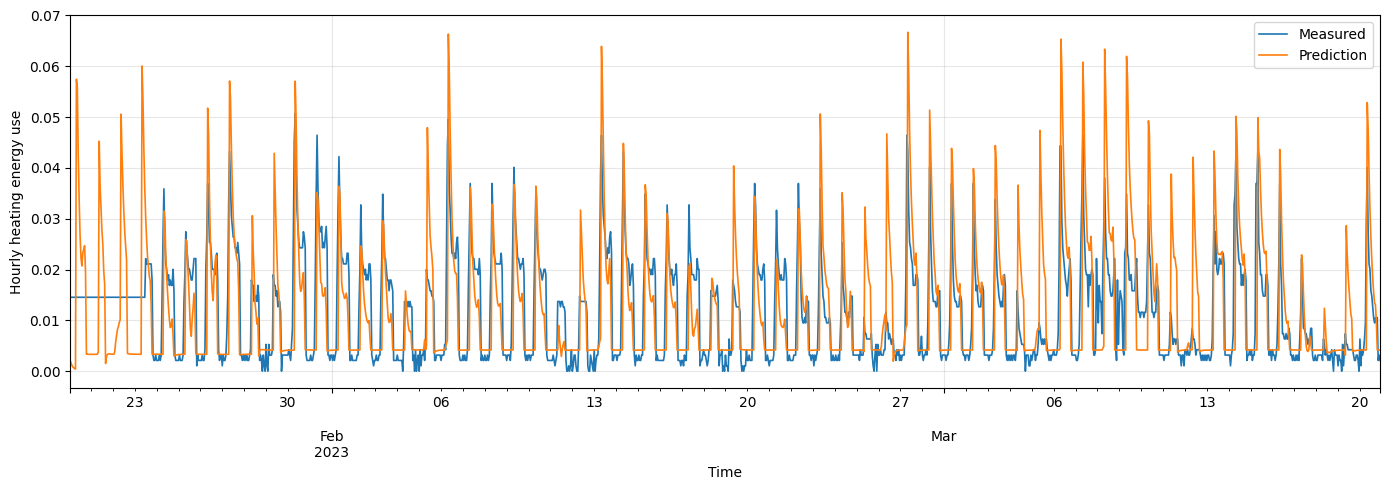

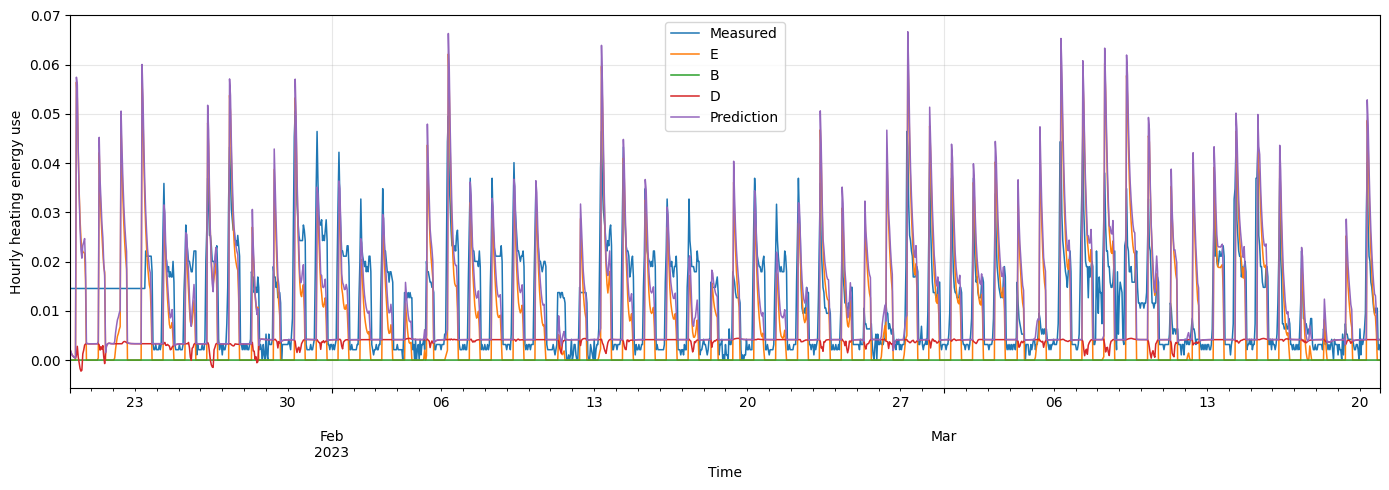

In [10]:
# ============================================================
# 8. Plots
# ============================================================

plot_columns = ["Measured", "Prediction"]
ax = post_smoke_diagnostics[plot_columns].plot(figsize=(14, 5), linewidth=1.2)
ax.set_xlabel("Time")
ax.set_ylabel("Hourly heating energy use")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_columns = ["Measured", "E", "B", "D", "Prediction"]
ax = post_smoke_diagnostics[plot_columns].plot(figsize=(14, 5), linewidth=1.1)
ax.set_xlabel("Time")
ax.set_ylabel("Hourly heating energy use")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
# ============================================================
# 9. Closed-loop and shape checks
# ============================================================

assert "HeatingEnergy" not in shadow_data.columns
assert "RC heating" not in shadow_data.columns
assert piml.model.last_E is not None, "RC cell was not called inside forward()."

x_one = piml.X[:1]
initial_rc_state = piml.model._initialise_rc_state(1)
rc_inputs_one = piml.model._rc_inputs(x_one.reshape(1, 1, -1))
E_one = piml.model._compute_physical_demand(rc_inputs=rc_inputs_one, rc_state=initial_rc_state)
state_from_E = piml.model._update_rc_state(q_prediction=E_one, rc_inputs=rc_inputs_one, rc_state=initial_rc_state)
state_from_extra_heat = piml.model._update_rc_state(q_prediction=E_one + 0.01, rc_inputs=rc_inputs_one, rc_state=initial_rc_state)
assert not torch.allclose(state_from_E, state_from_extra_heat), "q_pred does not affect rc_state_next."

pred_one, states_one = piml.model(piml.X[:1], states=None, warm_start=False)
pred_seq, _ = piml.predict(sequences=piml.train_sequences[0])
pred_batch, _ = piml.predict(sequences=piml.train_sequences[:2])
print("Shape checks:", pred_one.shape, pred_seq.shape, pred_batch.shape)
print("Closed-loop verification checks passed.")


Shape checks: torch.Size([1, 1]) torch.Size([1, 84, 1]) torch.Size([2, 84, 1])
Closed-loop verification checks passed.


In [12]:
# ============================================================
# Full training with diagnostics, disabled by default
# ============================================================

if RUN_FULL_TRAINING:
    full_info = fit_with_diagnostics(
        piml,
        n_epochs=150,
        number_sequences=None,
        output_best=True,
    )
    full_diagnostics = rollout_with_diagnostics(piml)
    full_plot_diagnostics = run_shadow_diagnostics(
        full_diagnostics,
        label="After full training",
        start=DIAGNOSTIC_START,
        end=DIAGNOSTIC_END,
    )


## Notes

This notebook uses `module_shadow___.py` for the current no-occupancy workflow. It does not copy the original `EPFLpiml/module.py` classes directly because those classes predict the final target, while the runtime shadow architecture needs a neural state for `B` and `D` before the RC state update.

`neural_backend="lstm"` is the standard recurrent backend. `neural_backend="pcnn"` is a PCNN-style feature backend: it combines an LSTM state with a positive recurrent accumulator, then passes that state to the baseline and discrepancy heads. The runtime RC branch remains the physical branch in all cases.